In [9]:
import eventIO
import numpy as np
import matplotlib.pyplot as plt
import cv2
import matplotlib.patches as patches

In [3]:
events = eventIO.load_hdf5("../data/output/max-recording-snippet.hdf5")

/tmp/ipykernel_46273/1356440766.py:20: RuntimeWarning: invalid value encountered in cast
  img[ind] = 125 + (2 * indsurface[ind] - 1) * np.exp(-(t + tw - tsurface[ind].astype(np.float32))/ (tw/30)) * 125


(-0.5, 1279.5, 719.5, -0.5)

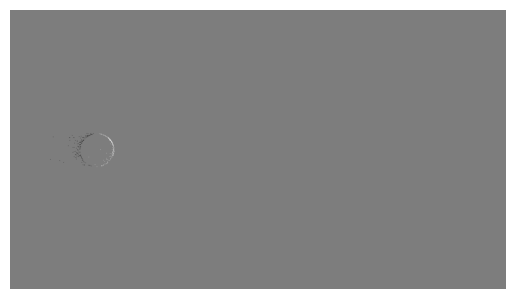

In [8]:
ts = events.get_ts()
x = events.get_x()
y = events.get_y()
p = events.get_p()

res = [720, 1280]
tw = 50
img = np.zeros((res[0], res[1]), dtype=np.uint8)
tsurface = np.zeros((res[0], res[1]), dtype=np.uint64)
indsurface = np.zeros((res[0], res[1]), dtype=np.uint64)
image = []

for t in range(ts[0], ts[-1], tw):
    ind = np.where((ts > t)&(ts < t + tw))
    tsurface[:, :] = 0
    tsurface[y[ind], x[ind]] = t + tw
    indsurface[y[ind], x[ind]] = p[ind]
    ind = np.where(tsurface > 0)
    img[:, :] = 125
    img[ind] = 125 + (2 * indsurface[ind] - 1) * np.exp(-(t + tw - tsurface[ind].astype(np.float32))/ (tw/30)) * 125
    img_c = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)
    #img_c = cv2.applyColorMap(img_c, cv2.COLORMAP_VIRIDIS)

    if t > (500 * 50) + ts[0]:
        image = img_c
        break

plt.imshow(image)
plt.axis('off')

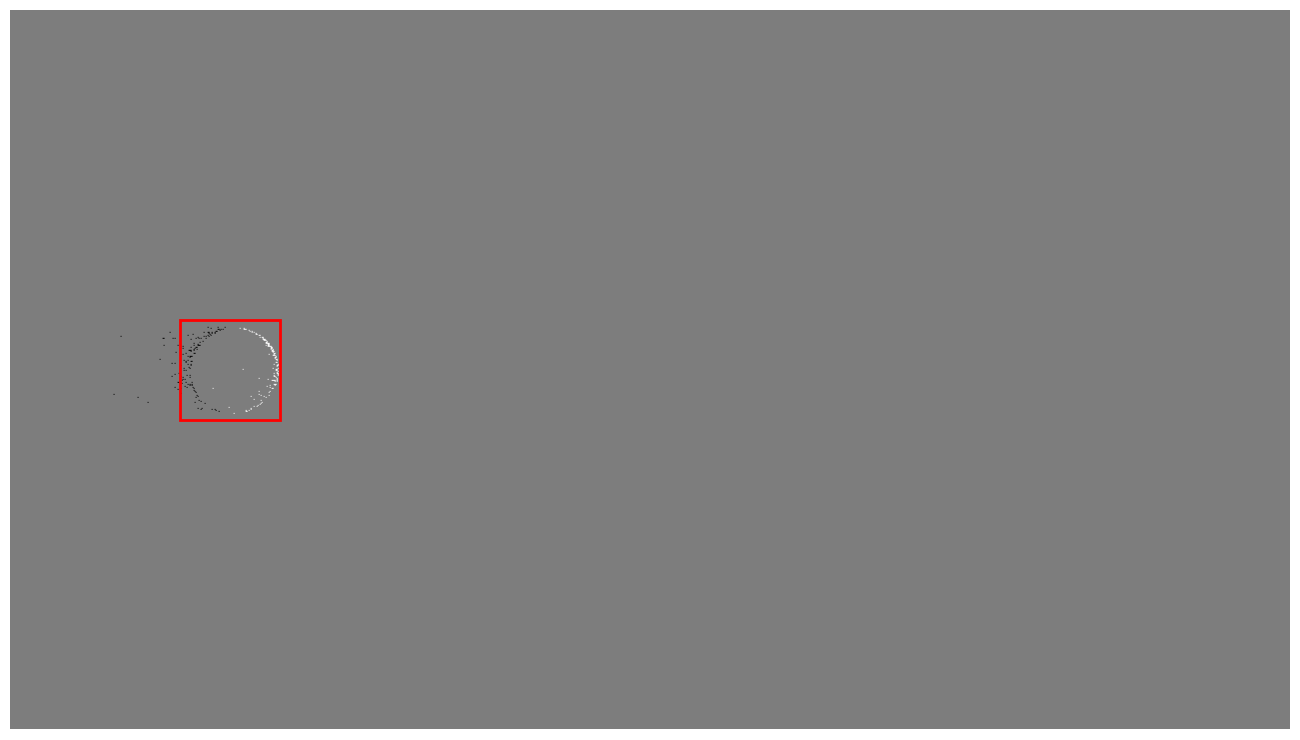

In [18]:
canvas_width = 1280  # Width in pixels
canvas_height = 720  # Height in pixels
dpi = 100  # Dots per inch for the figure

# Create figure and axes with specified DPI
fig = plt.figure(figsize=(canvas_width / dpi, canvas_height / dpi), dpi=dpi)
ax = fig.add_axes([0, 0, 1, 1])  # fill entire figure

# Turn off axis
ax.set_axis_off()

# Set limits to match pixel coordinates
ax.set_xlim(0, canvas_width)
ax.set_ylim(0, canvas_height)
ax.invert_yaxis()  # (0,0) at top-left like in image coordinates

# Draw a red square: 100x100 pixels starting at (50, 50)
square = patches.Rectangle((170, 310), 100, 100, linewidth=2, edgecolor='red', facecolor='none')
ax.imshow(image)
ax.add_patch(square)

plt.show()